# BULC-D Early Detection — test site (Earth Engine FeatureCollection)

A walkthrough of **BULC-D**, a Bayesian method for detecting landscape change from satellite imagery, using a study area supplied as an Earth Engine FeatureCollection (`projects/bulcd-python-rebuild/assets/testsite`: one polygon, 26 km², western Oregon) and the 2026 season. It is the same workflow, settings and structure as the Apostle Islands (`early_detection_demo.ipynb`) and North Cascades (`north_cascades_demo.ipynb`) notebooks.

1. **What is BULC-D?** How it decides whether a place has changed.
2. **Setup and parameters.** The settings that matter, in plain terms.
3. **Test site example.** The outputs: change map, 2024–2026 imagery, area totals, confidence, timing.
4. **Parameter effects.** The same place under different settings, side by side.
5. **Try your own area.** Draw an area, or use an Earth Engine asset.

*Prototype. The main result is precomputed, so running the notebook takes about two minutes. Results have not been field-checked.*

In [1]:
import dataclasses
import datetime
import json
from pathlib import Path
from pprint import pprint

import ee
ee.Initialize(project="bulcd-python-rebuild")

from IPython.display import Markdown, display

from bulcd_early_detection import compare, drawing, outputs, render, report
from bulcd_early_detection.config import MonitoringControls, build_config, config_summary

OUT = Path("output")

## 1. What is BULC-D?

BULC-D (Bayesian Updating of Land Cover — Disturbance) asks one question for every 30 m pixel: *compared with how this place normally looks at this time of year, has it changed?* It answers by weighing many satellite observations, not by comparing two images.

1. **Learn "normal" (the baseline, or expectation, period).** For each pixel, BULC-D fits a smooth seasonal curve to several years of a vegetation index (NBR, which responds to green vegetation, moisture and burning). That gives an expected value for any day of the year, and how much the pixel normally varies.
2. **Compare each new observation (the monitoring period).** Every clear satellite image in the monitoring season is compared with the expected value. The difference, scaled by the pixel's normal variability, is a **z-score**: near 0 is normal, large negative values mean "much less vegetation than usual", large positive values mean "more".
3. **Turn each observation into evidence.** The z-score falls into one of 10 bins, and a fixed table (the **transition matrix**) says how strongly that bin points to *decrease*, *unchanged* or *increase*. A slightly low value is weak evidence; an extremely low one is strong evidence for decrease.
4. **Update the odds (Bayesian updating).** Each pixel starts at even odds for the three outcomes. Each observation updates the three probabilities, which carry forward to the next observation. One odd observation (a cloud edge, a shadow) can't flip the answer; a consistent run of evidence does.
5. **Decide.** At the end of the season, a pixel is mapped as **decrease** or **increase** if that outcome's probability exceeds the **decision threshold** (0.5 here). Otherwise it's **unchanged**.

| Outcome | Meaning | Examples |
|---|---|---|
| **Decrease / disturbance** | Vegetation signal consistently below its normal range | harvest, blowdown, fire, insects or disease, flooding, clearing |
| **Unchanged** | Within its normal range | |
| **Increase / growth** | Consistently above its normal range | regrowth, recovery |

BULC-D detects *spectral* change. It does not say *what caused* it; that takes local knowledge or a site visit.

The figure below shows the process for one real pixel at a 2026 fire in Washington (not at this site). Before the fire, observations are near normal and *unchanged* stays most likely. After the fire, every observation is extreme, and the probability of *decrease* builds step by step until it crosses the threshold about four weeks later.

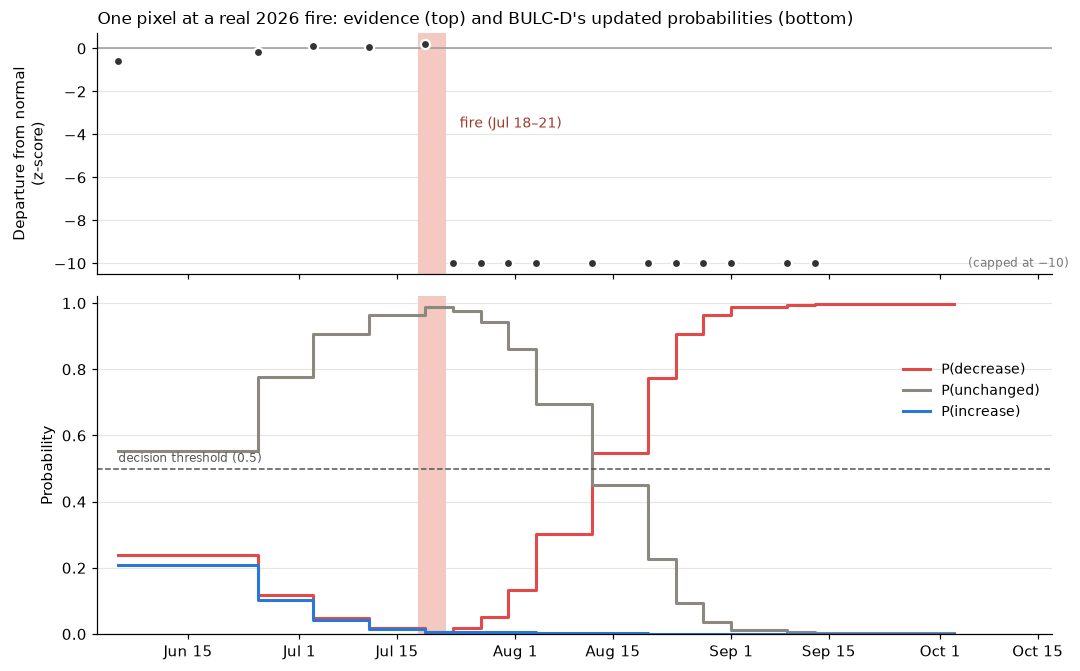

In [2]:
report.pixel_journey(Path("../experiments/output/fire_2026_production_matrix.csv"),
                     datetime.date(2026, 7, 18), datetime.date(2026, 7, 21), save_to=OUT / "pixel_journey.png");

## 2. BULC-D setup and parameters

The parameters that most affect the result, in plain terms. The first group are the everyday settings below; the rest are in the advanced configuration.

| Parameter | What it controls | This run |
|---|---|---|
| **Monitoring period** | The season checked for change | Jun 1 – Sep 30, 2026 |
| **Baseline period** | The years used to learn "normal", same season each year | 2018–2025 |
| **Decision threshold** | How sure BULC-D must be before a change is mapped | 0.5 |
| **Sensitivity** (`z_score_numerator_factor`) | Scales every departure from normal before it's scored. Higher flags smaller departures | 1.0 |
| *Advanced:* transition matrix | How strongly each level of departure counts as evidence | legacy app's default |
| *Advanced:* dampening (`dampening_factor`) | How much each single observation may move the probabilities (1 = full weight) | 0.5 |
| *Advanced:* posterior leveler (`posterior_leveler`) | After each update, pulls the probabilities slightly back toward even, so they don't lock in and a pixel can change its mind (1 = off) | 1.0 (off) |
| *Advanced:* sensors | Satellites used in each period | baseline Landsat 8; monitoring Landsat 8, Landsat 9, Sentinel-2 |
| *Advanced:* masks | Areas left out | water; non-forest land |

These are the same default settings as the other example notebooks; nothing was adjusted for this site. Section 4 shows what several of them do to the map.

In [3]:
# Everyday settings, used by every section below.
controls = MonitoringControls(
    monitoring_year=2026,       # the season being checked for change
    season_start="06-01",       # MM-DD; the same window is used in every baseline year
    season_end="09-30",
    baseline_first_year=2018,   # "normal" is learned from these years (inclusive)
    baseline_last_year=2025,
    decision_threshold=0.5,     # map a change only where its probability exceeds this (0.5-0.99)
    sensitivity=1.0,            # z_score_numerator_factor; >1 flags smaller departures
)

### Advanced configuration

The settings above become a complete BULC-D configuration (`bulcd.config.schema.BULCDConfig`). Every BULC-D parameter stays available: edit it in `advanced()` and the change applies everywhere in this notebook. The full configuration is printed in section 3.

In [4]:
def advanced(config):
    # Edit any BULC-D config field here. Examples:
    # config.bulc_advanced_params.posterior_leveler = 0.9
    # config.evidence.target.sensors["S2"].enabled = False
    # config.study_area.mask_non_forest = False
    return config


def build(controls, **aoi):
    return advanced(build_config(controls, **aoi))

### Known differences from the legacy GEE app

This is a Python rebuild of BULC-D. It matches the legacy Google Earth Engine app in the transition matrix (traced to the app's own source; this matrix and configuration reproduced a legacy map with 97.9% agreement) and in how evidence is built. Known differences:

- **Levelers:** the legacy app uses a dampening (transition) leveler of 0.7, a posterior leveler of 0.9 and an initializing leveler of 0.7. This run uses 0.5, off, and off. How the rebuild should represent all three is still being reconciled.
- **Baseline sensors:** Landsat 8 only, because a Landsat + Sentinel-2 multi-year baseline exceeded an Earth Engine memory limit. Monitoring uses Landsat 8, Landsat 9 and Sentinel-2. Tests on small areas suggest this mismatch creates some spurious early-season detections; this is under investigation (`docs/findings.md`).
- **Masks:** water uses JRC Global Surface Water. The forest mask (Hansen tree cover in 2000) is a setting, not a BULC-D requirement; the legacy app has none. Non-forest land (about 8% of this site) is not analyzed in this run.
- **Study boundary:** the supplied FeatureCollection, used as is. BULC-D runs directly on it.

## 3. Test site example

The whole study area, from a result computed in advance with the settings above. The notebook checks that the precomputed result matches the current settings.

In [5]:
STUDY_AREA_ASSET = "projects/bulcd-python-rebuild/assets/testsite"
PRECOMPUTED_FOLDER = "projects/bulcd-python-rebuild/assets/testsite_bulcd"
PRECOMPUTED_RUN = "testsite_2026_v1"

park = outputs.from_asset(STUDY_AREA_ASSET)
park_config = build(controls, **park.aoi)
results, run_meta = outputs.load_precomputed(PRECOMPUTED_FOLDER, PRECOMPUTED_RUN)

expected = outputs.run_metadata(controls, park_config)
if not all(json.loads(m["controls_json"]) == json.loads(expected["controls_json"])
           and json.loads(m["config_json"]) == json.loads(expected["config_json"]) for m in run_meta):
    print("WARNING: the settings differ from the precomputed run. The maps in this section show the "
          "PRECOMPUTED settings; regenerate it with the maintenance cell at the end.")

size = outputs.aoi_size_report(park)
w, s, e, n = size["bbox_degrees"]
print(f"Study area {STUDY_AREA_ASSET}: {size['area_km2']:,.1f} km², extent {w:.3f}, {s:.3f} to {e:.3f}, {n:.3f}")
display(Markdown("**Settings for this run**\n\n| Setting | Value |\n|---|---|\n"
                 + "\n".join(f"| {k} | {v} |" for k, v in config_summary(park_config))))

token = render.auth_token()
frame, bbox = report.frame_for(park.geometry, pad_m=150)
season = report.season_label(controls)
park_out = OUT / f"testsite_{controls.monitoring_year}"

Study area projects/bulcd-python-rebuild/assets/testsite: 26.3 km², extent -123.590, 44.814 to -123.515, 44.855


**Settings for this run**

| Setting | Value |
|---|---|
| Baseline (expectation) period | L8; years [(2018, 2025)]; DOY [(152, 273)] |
| Monitoring (target) period | L8, L9, S2; years [(2026, 2026)]; DOY [(152, 273)] |
| Spectral index | NBR |
| Expectation model | constant, unimodal |
| Sensitivity (z-score numerator factor) | 1.0 |
| Transition matrix | production (legacy default) |
| dampening_factor | 0.5 |
| posterior_leveler | 1.0 |
| initializing_leveler | 0.0 |
| recency_factor | 1.0 |
| Water mask / non-forest mask | True / True |

In [6]:
# Full BULC-D configuration, for technical users.
pprint(dataclasses.asdict(park_config), width=110, compact=True)

{'bin_cuts': [-2, -1.5, -1, -0.5, 0, 0.5, 1, 1.5, 2],
 'bulc_advanced_params': {'custom_transition_matrix': [[0.83, 0.08, 0.08], [0.66, 0.24, 0.08],
                                                       [0.53, 0.37, 0.08], [0.14, 0.76, 0.08],
                                                       [0.08, 0.83, 0.08], [0.08, 0.83, 0.08],
                                                       [0.08, 0.76, 0.14], [0.08, 0.37, 0.53],
                                                       [0.08, 0.24, 0.66], [0.08, 0.08, 0.83]],
                          'dampening_factor': 0.5,
                          'initializing_leveler': 0.0,
                          'posterior_leveler': 1.0,
                          'raw': {},
                          'recency_factor': 1.0},
 'evidence': {'day_step_size': 4,
              'expectation': {'sensors': {'L8': {'cloud_cover_threshold': 70,
                                                 'enabled': True,
                                               

### Change this season

**The primary map.** Red: decrease/disturbance. Blue: increase/growth. Gray: unchanged. Lighter gray: land not analyzed (non-forest). Water is pale blue and not analyzed.

*This site is small enough that the maps show true 30 m extents; nothing is enlarged.*

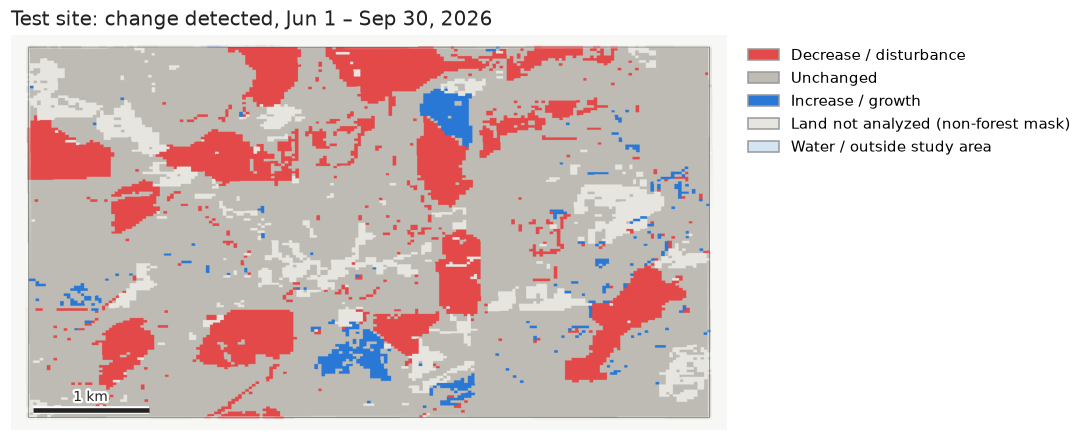

In [7]:
report.outcome_map(results, park, frame, bbox, f"Test site: change detected, {season}", token,
                   save_to=park_out / "outcome.png", enlarge_changes=False);

### What the landscape looked like: 2024 | 2025 | 2026

True-color Sentinel-2 (red, green, blue) at exactly the same extent as the map above, with **one fixed stretch** for all three years, so differences are real differences on the ground. Each year uses a single clear date: **September 16**, the same day of year each time, near the end of the monitoring season. All three are fully cloud-free over the site (Cloud Score+) with low haze. Compare them with the change map: places that turn bare or brown between years, and places that green up.

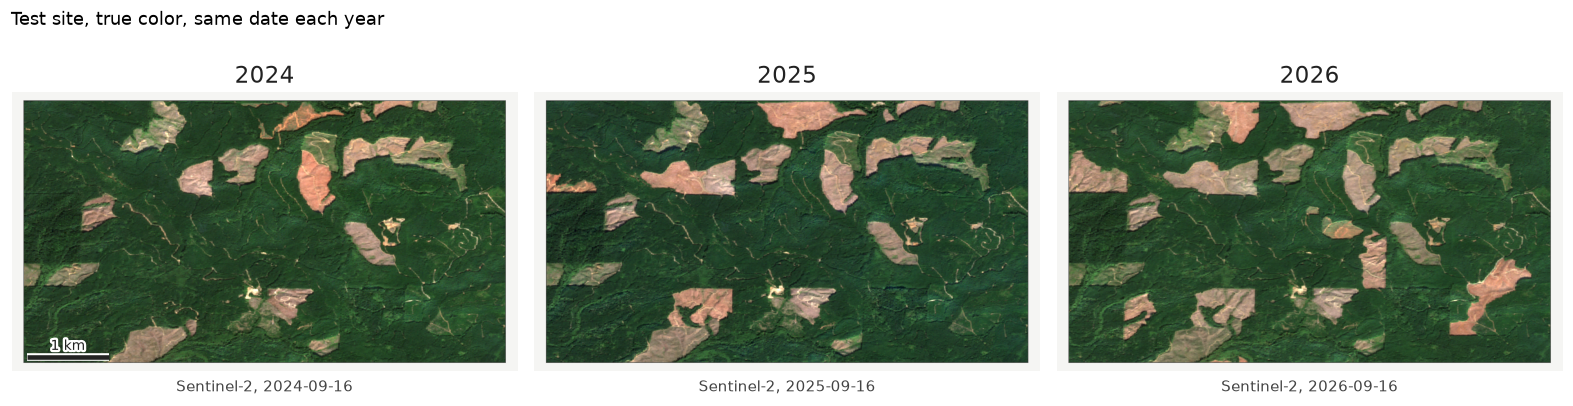

In [8]:
RGB_SCENES = [("2024", "20240916T191031_20240916T191702_T10TDQ"), ("2025", "20250916T190929_20250916T191932_T10TDQ"), ("2026", "20260916T191031_20260916T191726_T10TDQ")]
report.scene_row(park, frame, bbox, token, RGB_SCENES, suptitle="Test site, true color, same date each year",
                 save_to=park_out / "rgb_2024_2025_2026.png");

### Area by outcome
Land only; water is excluded.

In [9]:
table, park_areas = report.area_table(results, park.geometry)
display(Markdown(table))

| Outcome | Area (km²) | Share of analyzed land |
|---|---:|---:|
| Decrease / disturbance | 4.75 | 19.6% |
| Unchanged | 18.75 | 77.5% |
| Increase / growth | 0.68 | 2.8% |
| Land not analyzed (non-forest mask) | 2.21 | — |

### How confident is each mapped change?
The final probability of each mapped change; darker is more certain. Only change pixels are colored.

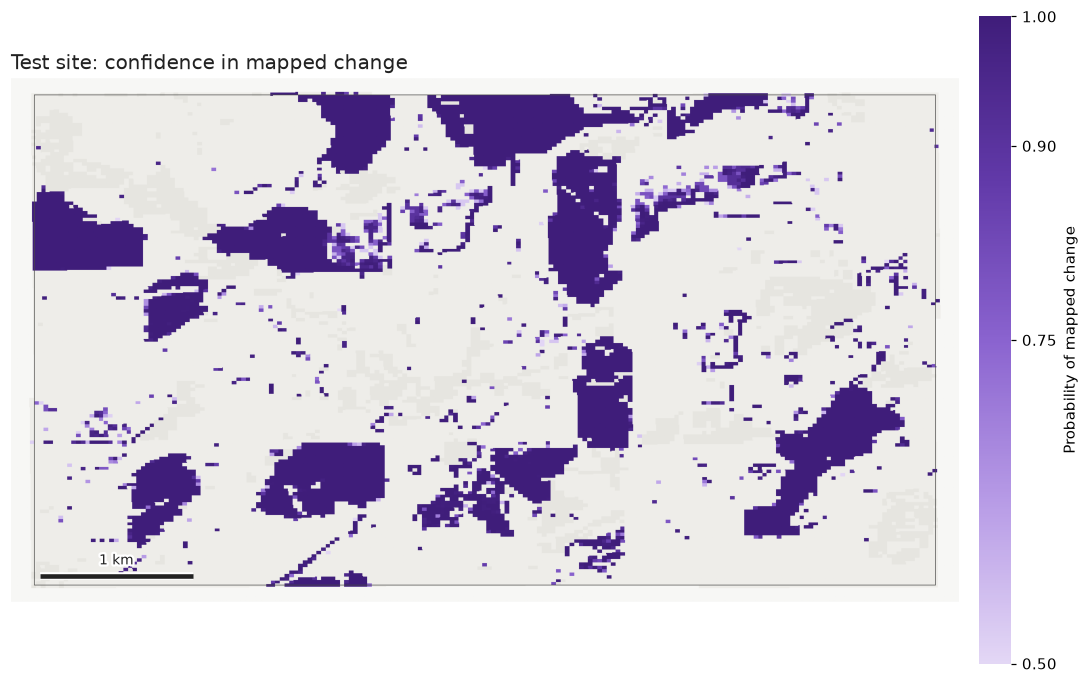

In [10]:
report.confidence_map(results, park, frame, bbox, "Test site: confidence in mapped change", token,
                      controls.decision_threshold, save_to=park_out / "confidence.png", enlarge_changes=False);

### When was each change first detected?
The first date a pixel's change probability passed the decision threshold (4-day resolution). A change that *happens during* the season is usually detected a few weeks later (section 1). A change detected in the **first days of the season** was most likely already different from normal when observations began.

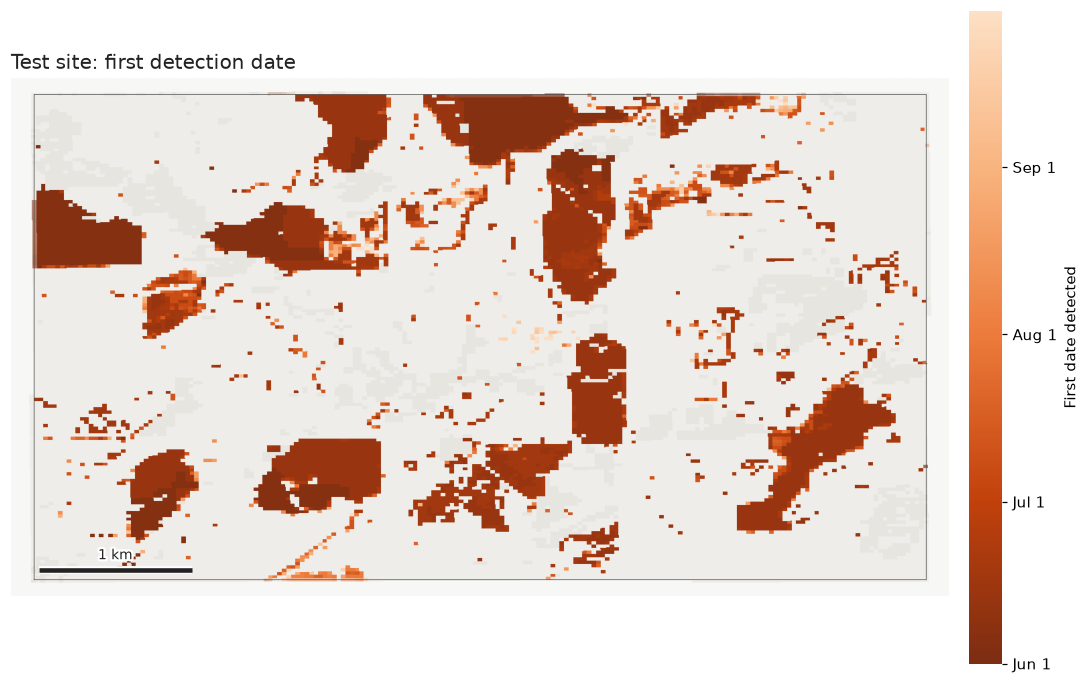

Mapped change: 5.43 km², of which 64% was first detected in the first two weeks of the season.


In [11]:
report.timing_map(results, park, frame, bbox, "Test site: first detection date", token, controls,
                  save_to=park_out / "first_detection.png", enlarge_changes=False)
timing = outputs.early_detection_share(results, park.geometry, controls.first_doy)
print(f"Mapped change: {timing['changed_km2']:.2f} km², of which {100 * timing['early_share']:.0f}% was first "
      "detected in the first two weeks of the season.")

### What this run shows (prepared 2026-09-29)

These notes describe the precomputed 2026 result with the default settings, which were **not** adjusted for this site.

- **About 20% of analyzed forest is mapped as decrease** (4.75 km² of 24.2 km²) and about 3% as increase (0.68 km²). About 2.2 km² is not analyzed (non-forest).
- **The decrease is concentrated in distinct, sharp-edged patches.** Most of them line up with patches that are green in the 2024 image and bare or brown in the 2025 or 2026 image.
- **The larger increase patches** sit where the 2024 image shows bare ground that is greener by 2026.
- **About 64% of the change was first detected in the first two weeks of June.** That fits patches that were already bare before the 2026 season began: they differ from their 2018–2025 normal from the first observation.
- Scattered single pixels and a few thin lines are also flagged; they have not been checked. **Nothing here has been field-checked, and no cause is assigned.**

## 4. Parameter effects

What changes when BULC-D's settings change? Each map below is **the whole study area at exactly the same extent**, with **one** setting changed from section 2 and everything else held the same. These are the same six maps as in the other example notebooks. The goal is to show what each parameter does, not to pick the "best" settings.

| Map | What changed | What that parameter means |
|---|---|---|
| **Current settings** | Nothing (reference) | The settings in section 2. |
| **Decision threshold 0.9** | 0.5 → 0.9 | How sure BULC-D must be before mapping a change. Higher maps only the strongest evidence. |
| **Sensitivity 0.5** | 1.0 → 0.5 | Halves every departure from normal before it's scored, so only large departures count as strong evidence. |
| **Sensitivity 2.0** | 1.0 → 2.0 | Doubles every departure, so small departures count as strong evidence. |
| **Dampening 0.7** | 0.5 → 0.7 (the legacy app's value) | How much weight each single observation carries. Higher lets each observation move the probabilities further. |
| **Posterior leveler 0.9** | off → 0.9 (the legacy app's value) | After each observation, pulls the probabilities slightly back toward even, so evidence must keep accumulating. |

Each setting that changes BULC-D's inputs is a new Earth Engine run (about 10 s here). The threshold only re-reads existing probabilities, so it's free.

*These comparison runs use their own 30 m pixel grid, so the "Current settings" totals differ from the precomputed result in section 3 by about 0.6% (e.g. 4.78 vs 4.75 km² decrease). That's grid alignment, not a different result.*

Current settings: running BULC-D ... 

30 s
Decision threshold 0.9: reusing an earlier run (differs only in threshold/masks)
Sensitivity 0.5: running BULC-D ... 

14 s
Sensitivity 2.0: running BULC-D ... 

10 s
Dampening 0.7: running BULC-D ... 

6 s
Posterior leveler 0.9: running BULC-D ... 

11 s


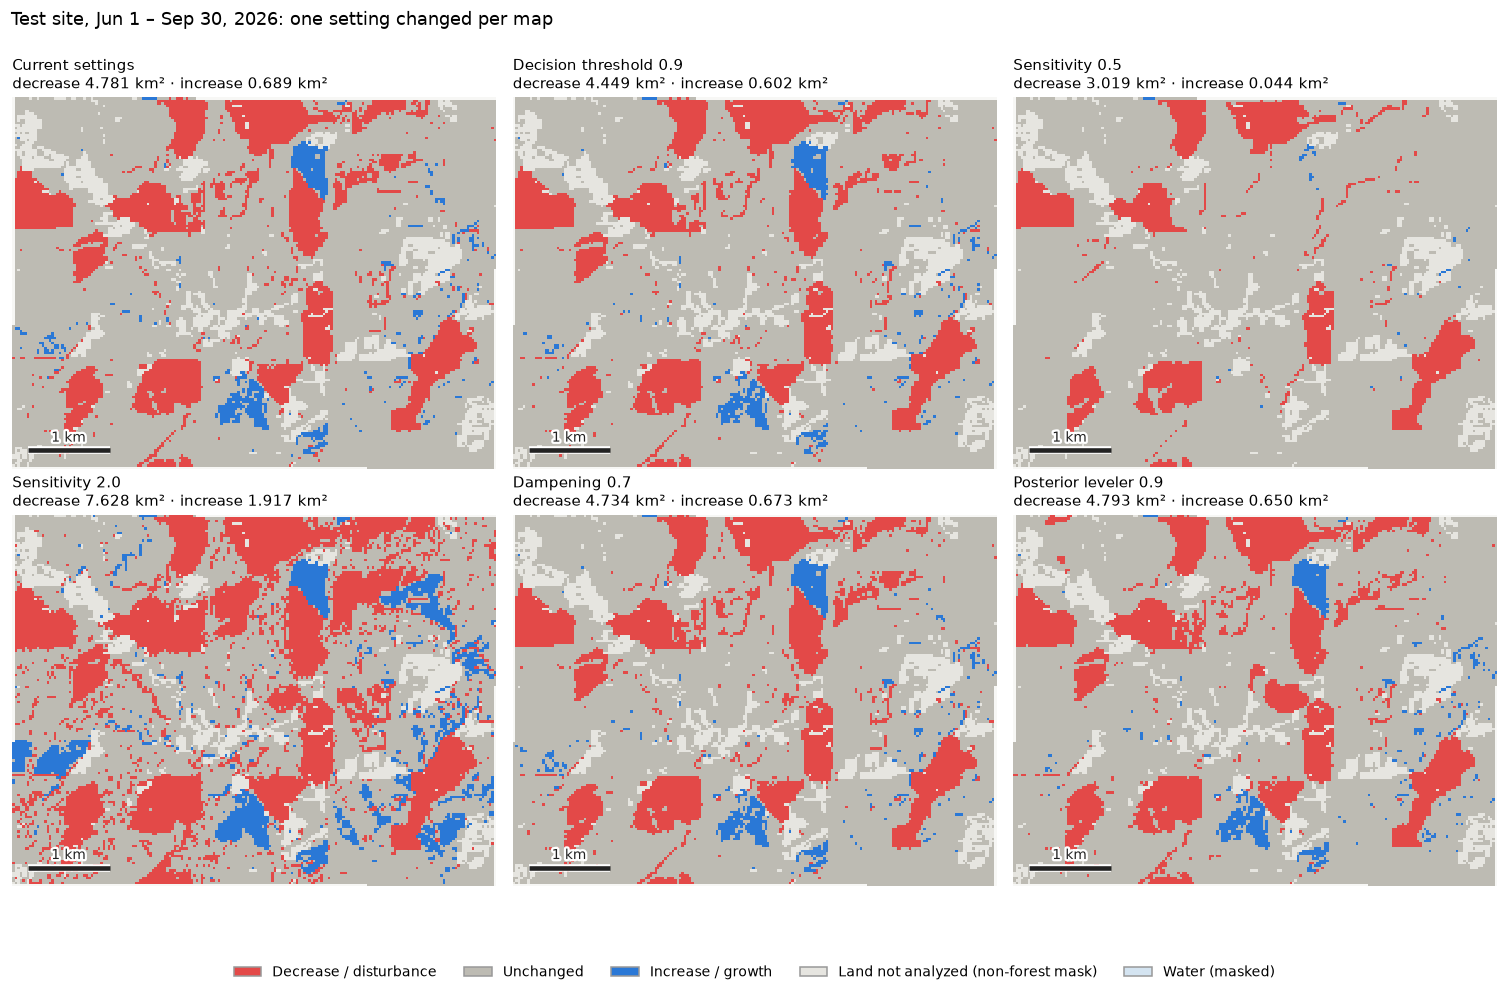

| Variant | Decrease / disturbance (km²) | Increase / growth (km²) | Unchanged (km²) | Land not analyzed (non-forest mask) (km²) | What it tests |
|---|---:|---:|---:|---:|---|
| Current settings | 4.781 | 0.689 | 18.992 | 2.227 | Reference: the section 2 settings. |
| Decision threshold 0.9 | 4.449 | 0.602 | 19.410 | 2.227 | Higher bar before a change is mapped. |
| Sensitivity 0.5 | 3.019 | 0.044 | 21.398 | 2.227 | Departures from normal halved. |
| Sensitivity 2.0 | 7.628 | 1.917 | 14.916 | 2.227 | Departures from normal doubled. |
| Dampening 0.7 | 4.734 | 0.673 | 19.054 | 2.227 | Each observation weighs more (legacy value). |
| Posterior leveler 0.9 | 4.793 | 0.650 | 19.019 | 2.227 | Probabilities pulled toward even after each update (legacy value). |

In [12]:
def set_advanced(field, value):
    def edit(config):
        setattr(config.bulc_advanced_params, field, value)
    return edit


V = compare.Variant
parameter_variants = [
    V("Current settings", "Reference: the section 2 settings."),
    V("Decision threshold 0.9", "Higher bar before a change is mapped.", controls={"decision_threshold": 0.9}),
    V("Sensitivity 0.5", "Departures from normal halved.", controls={"sensitivity": 0.5}),
    V("Sensitivity 2.0", "Departures from normal doubled.", controls={"sensitivity": 2.0}),
    V("Dampening 0.7", "Each observation weighs more (legacy value).", edit=set_advanced("dampening_factor", 0.7)),
    V("Posterior leveler 0.9", "Probabilities pulled toward even after each update (legacy value).",
      edit=set_advanced("posterior_leveler", 0.9)),
]

effects = compare.run_comparison(park, controls, build, parameter_variants)
compare.show_comparison(effects, f"Test site, {season}: one setting changed per map", save_to=park_out / "parameter_effects.png")
display(Markdown(compare.comparison_table(effects)))

**How to read it** (observed with the section 2 settings):

- **Sensitivity has the largest effect,** as in the other notebooks. Halving it keeps the large patches but drops many scattered pixels and nearly all increase (decrease 4.8 → 3.0 km²). Doubling it adds many scattered detections and new increase (decrease 7.6 km², increase 1.9 km²).
- **The decision threshold trims only the edges** (4.8 → 4.4 km²). Evidence inside the large patches is strong.
- **Dampening and the posterior leveler barely change this site** (4.7–4.8 km²).
- **The large patches persist under every setting.** They are also the patches most clearly visible in the 2024–2026 imagery above.

## 5. Try your own area

The same workflow can run on any area, **live** (a few minutes for a few km²). Two ways to define it:

- **Draw it:** set `TRY_OWN_AREA = True` and `AOI_MODE = "draw"`, and choose a new `DRAWN_AOI_NAME`. Run the next cell, draw a polygon or rectangle on the map, then run the save cell. The area is saved as `aois/<name>.geojson` and can be reloaded by name later, with no redrawing.
- **Use an Earth Engine asset:** set `AOI_MODE = "asset"` and `CUSTOM_AOI_ASSET` to a FeatureCollection asset ID.

Then run the remaining cells. The size is checked first: areas over 100 km² get a warning, and areas over 1,000 km² are blocked unless `ALLOW_LARGE_AOI = True`. Drawing needs JupyterLab 4, Notebook 7 or VS Code.

In [13]:
TRY_OWN_AREA = False
AOI_MODE = "draw"                        # "draw" or "asset"
DRAWN_AOI_NAME = "my_area"               # saved as aois/<name>.geojson
CUSTOM_AOI_ASSET = "projects/your-project/assets/your_feature_collection"
ALLOW_LARGE_AOI = False
COMPARE_OWN_AREA = False                 # also run section 4's variants on your area

if TRY_OWN_AREA and AOI_MODE == "draw":
    saved = drawing.aoi_path(DRAWN_AOI_NAME)
    detections = results.select("outcome")
    detections = detections.updateMask(detections.eq(outputs.DECREASE).Or(detections.eq(outputs.INCREASE)))
    overlay = drawing.ee_tile_layer(
        detections.visualize(min=0, max=2, palette=[render.OUTCOME_COLORS[0][1:], "ffffff", render.OUTCOME_COLORS[2][1:]]),
        "Test site 2026 detections")
    drawer = drawing.AOIDrawer(center=(44.834, -123.552), zoom=13, overlays=[overlay], existing=drawing.load_polygon(DRAWN_AOI_NAME) if saved.exists() else None)
    display(drawer.map)
    print(f"Saved area {DRAWN_AOI_NAME!r}: {'found (yellow)' if saved.exists() else 'not saved yet - draw one, then run the next cell'}")
elif not TRY_OWN_AREA:
    print("Skipped (set TRY_OWN_AREA = True).")

Skipped (set TRY_OWN_AREA = True).


In [14]:
# Run after drawing, to save the drawn shape as DRAWN_AOI_NAME.
if TRY_OWN_AREA and AOI_MODE == "draw":
    path = drawer.save(DRAWN_AOI_NAME)
    if path:
        print(f"Saved {path}")
    elif drawing.aoi_path(DRAWN_AOI_NAME).exists():
        print(f"Nothing new drawn - using the saved {DRAWN_AOI_NAME!r}.")
    else:
        print("Nothing drawn yet: draw on the map above, then run this cell again.")

In [15]:
if TRY_OWN_AREA:
    own = drawing.study_area(DRAWN_AOI_NAME) if AOI_MODE == "draw" else outputs.from_asset(CUSTOM_AOI_ASSET)
    own_size = outputs.aoi_size_report(own)
    print(f"Area {own.name!r}: {own_size['area_km2']:,.1f} km² (bounding box {own_size['bbox_km2']:,.1f} km²)")
    if own_size["verdict"] == "slow":
        print(f"WARNING: larger than anything run live so far (~{outputs.TESTED_LIVE_KM2} km²); maps may be slow or time out.")
    elif own_size["verdict"] == "large" and not ALLOW_LARGE_AOI:
        raise RuntimeError(f"Area is {own_size['area_km2']:,.0f} km² (> {outputs.LARGE_AOI_KM2:,} km²). "
                           "Use a smaller area, or set ALLOW_LARGE_AOI = True to try anyway.")

    own_results = outputs.outcome_image(build(controls, **own.aoi), controls.decision_threshold).clip(own.geometry)
    own_frame, own_bbox = report.frame_for(own.geometry)
    own_out = OUT / f"{own.name}_{controls.monitoring_year}"
    report.outcome_map(own_results, own, own_frame, own_bbox, f"{own.name}: change detected, {season}", token,
                       save_to=own_out / "outcome.png", enlarge_changes=False)
    display(Markdown(report.area_table(own_results, own.geometry)[0]))
    report.reference_pair(own, own_frame, own_bbox, own.name, token, controls, own_out)

    if COMPARE_OWN_AREA:
        if own_size["verdict"] != "ok" and not ALLOW_LARGE_AOI:
            raise RuntimeError(f"Comparisons are limited to {outputs.TESTED_LIVE_KM2} km²; draw a smaller area.")
        own_effects = compare.run_comparison(own, controls, build, parameter_variants)
        compare.show_comparison(own_effects, f"{own.name}, {season}: one setting changed per map",
                                save_to=own_out / "parameter_effects.png")
        display(Markdown(compare.comparison_table(own_effects)))
else:
    print("Skipped (set TRY_OWN_AREA = True).")

Skipped (set TRY_OWN_AREA = True).


---
## Appendix: regenerate the precomputed result

Only needed after changing settings. Starts an Earth Engine batch export (about 2 minutes for this site). Change `PRECOMPUTED_RUN` to keep the old result.

In [16]:
RUN_EXPORT = False

if RUN_EXPORT:
    tasks = outputs.export_study_area(controls, build, park, PRECOMPUTED_FOLDER, PRECOMPUTED_RUN)
    print(outputs.wait_for(tasks))